In [32]:
import pandas as pd
import sqlite3

In [33]:
conn = sqlite3.connect('data/checking-logs.sqlite')

In [34]:
merged_data = pd.io.sql.read_sql(
    """
    WITH views_per_day AS (
        SELECT DATE(datetime) AS date, COUNT(*) AS views
        FROM pageviews
        WHERE uid LIKE 'user_%'
        GROUP BY DATE(datetime)
    ),
    commits_per_day AS (
        SELECT DATE(timestamp) AS date, COUNT(*) AS commits
        FROM checker
        WHERE uid LIKE 'user_%'
        GROUP BY DATE(timestamp)
    )
    SELECT v.date, v.views, c.commits
    FROM views_per_day v
    INNER JOIN commits_per_day c ON v.date = c.date
    """,
    conn,
    parse_dates=['date']
)
merged_data


,date,views,commits
0,2020-04-17,1,23
1,2020-04-18,23,69
2,2020-04-19,15,33
3,2020-04-21,3,25
4,2020-04-22,1,28
5,2020-04-23,5,43
6,2020-04-25,1,104
7,2020-04-26,8,261
8,2020-04-28,2,5
9,2020-04-29,4,17


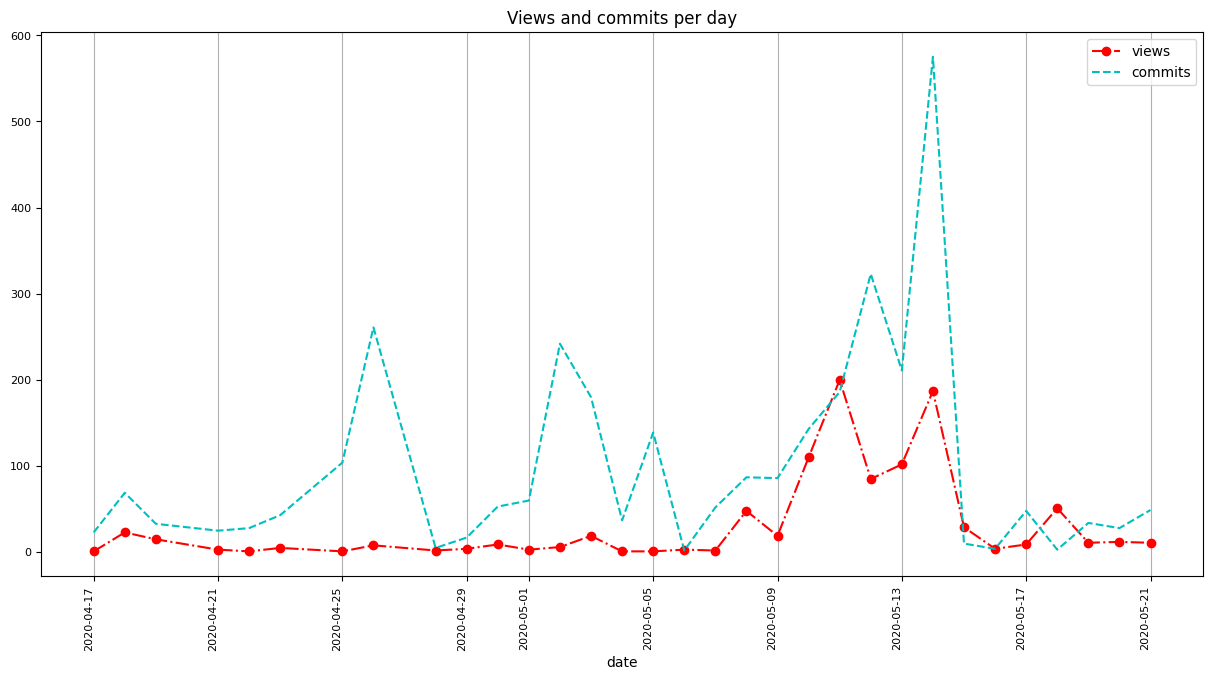

In [35]:
merged_data.set_index('date', inplace=True)
ax = merged_data.plot(figsize=(15, 8),
    fontsize=8,
    title='Views and commits per day',
    rot=90,
    style={'views': 'ro-.', 'commits': 'c--'},
)
ax.grid(axis='x')

In [36]:
conn.close()

Сколько раз количество просмотров превышало 150?

Ответ: 2.